# EDA

## Overview

### Objective

Perform EDA on portfolio and benchmark data to understand volatality, correlations and sector behaviour.

## Loading dataset

In [8]:
import pandas as pd

stocks_df = pd.read_csv("../data/raw/stock_data.csv", sep=",")
benchmark_df = pd.read_csv("../data/raw/benchmark_data.csv", sep=",")
portfolio_df = pd.read_csv("../data/raw/portfolio_holdings.csv", sep=",")

print("=" * 60)
print("Stocks")
display(stocks_df.head(5))
print("=" * 60)
print("Benchmark")
display(benchmark_df.head(5))
print("=" * 60)
print("Portfolio holdings")
display(portfolio_df.head(5))
print("=" * 60)

Stocks


,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,AAPL,71.344062,72.394093,71.091191,72.333885,135480400
1,2020-01-03,AAPL,71.563205,72.389257,71.406666,71.630638,146322800
2,2020-01-06,AAPL,70.754021,72.239950,70.503554,72.201416,118387200
3,2020-01-07,AAPL,72.211041,72.466322,71.642681,71.861839,108872000
4,2020-01-08,AAPL,71.565621,73.318877,71.565621,73.017838,132079200


Benchmark


,Date,Open,High,Low,Close,Volume
0,2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3459930000
1,2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3484700000
2,2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3702460000
3,2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3435910000
4,2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3726840000


Portfolio holdings


,Ticker,Shares,Purchase_Price,Purchase_Date
0,AAPL,50,180,2023-05-01
1,MSFT,30,320,2023-06-15
2,NVDA,20,450,2024-01-10
3,JPM,25,180,2023-08-01
4,BAC,40,32,2023-09-15


In [9]:
%run -i "../src/config.py"

## Data Preparation

In [10]:
# converting dates from string to datetime format
stocks_df["Date"] = pd.to_datetime(stocks_df["Date"])
benchmark_df["Date"] = pd.to_datetime(benchmark_df["Date"])

In [11]:
# sorting stocks based upon Ticker, Date
stocks_df = stocks_df.sort_values(["Ticker", "Date"])
benchmark_df = benchmark_df.sort_values("Date")

## Price Trend analysis
Objective: Understand how stock prices evolved over time

### Closing price trends

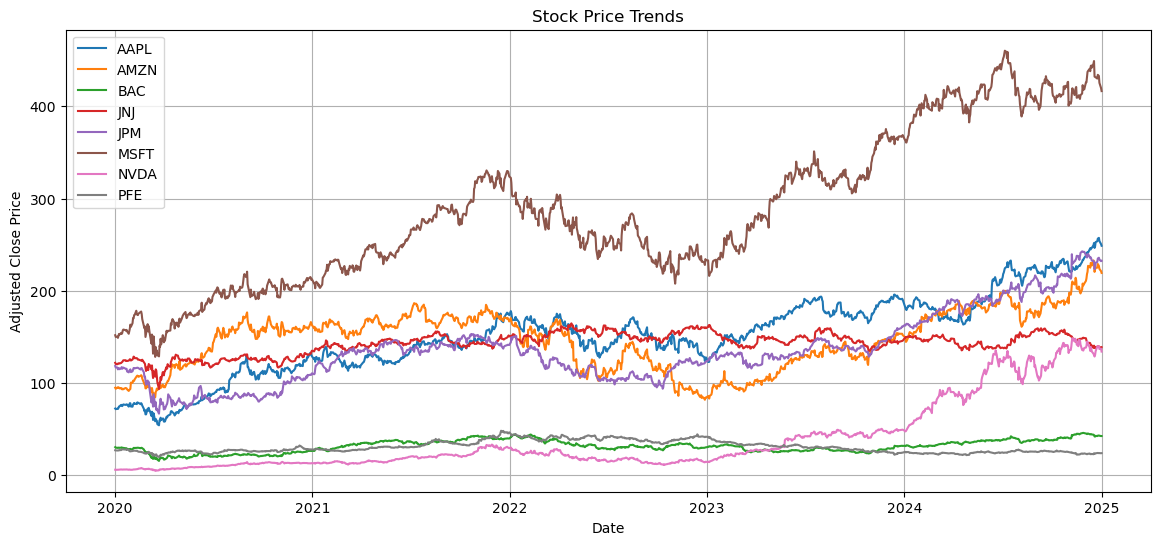

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for ticker in stocks_df["Ticker"].unique():
    data = stocks_df[stocks_df["Ticker"] == ticker]

    plt.plot(data["Date"], data["Close"], label=ticker)

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
price_summary = pd.DataFrame()

##### Highest Closing Price

In [14]:
# Highest Closing Price
highest_closing_price_ind = stocks_df.groupby("Ticker")["Close"].idxmax()
highest_closing_price = stocks_df.loc[highest_closing_price_ind, ["Ticker", "Date", "Close"]].rename(columns={"Close": "Highest_Close_Price"})
highest_closing_price.index = highest_closing_price["Ticker"]
del highest_closing_price["Ticker"]
price_summary["Highest_Close_Price"] = highest_closing_price["Highest_Close_Price"]
highest_closing_price

,Date,Highest_Close_Price
Ticker,,
AAPL,2024-12-26,257.375580
AMZN,2024-12-16,232.929993
BAC,2024-11-27,45.930729
JNJ,2022-04-25,164.681686
JPM,2024-11-25,242.758469
MSFT,2024-07-05,460.325592
NVDA,2024-11-07,148.647751
PFE,2021-12-16,48.252922


##### Lowest Closing Price

In [15]:
# Lowest Closing Price
lowest_close_price_id = stocks_df.groupby("Ticker")["Close"].idxmin()
lowest_close_price = stocks_df.loc[lowest_close_price_id, ["Ticker", "Date", "Close"]].rename(columns={"Close": "Lowest_Close_Price"})
lowest_close_price.index = lowest_close_price["Ticker"]
del lowest_close_price["Ticker"]
price_summary["Lowest_Close_Price"] = lowest_close_price["Lowest_Close_Price"]
lowest_close_price

,Date,Lowest_Close_Price
Ticker,,
AAPL,2020-03-23,54.163704
AMZN,2022-12-28,81.820000
BAC,2020-03-23,15.535211
JNJ,2020-03-23,93.433510
JPM,2020-03-23,66.763321
MSFT,2020-03-16,128.358322
NVDA,2020-03-16,4.885129
PFE,2020-03-23,19.889620


##### Appreciation across all years

In [16]:
# Appreciation across all years 
temp = stocks_df.groupby("Ticker").agg(Start_Price=("Close", "first"), End_Price=("Close", "last"))
price_summary["Start_Price"] = temp["Start_Price"]
price_summary["End_Price"] = temp["End_Price"]
price_summary["Absolute_Gain"] = price_summary["End_Price"] - price_summary["Start_Price"]
price_summary["Price_Appreciation_%"] = (price_summary["Absolute_Gain"] / price_summary["Start_Price"]) * 100

##### CAGR

In [17]:
# Annual Growth Rate (CAGR)
no_of_years = int(END_DATE.split("-")[0]) - int(START_DATE.split("-")[0]) + 1
price_summary["CAGR"] = ((price_summary["End_Price"] / price_summary["Start_Price"])**(1/no_of_years)) - 1
price_summary["CAGR"]

Ticker
AAPL    0.228646
AMZN    0.149895
BAC     0.057232
JNJ     0.021804
JPM     0.118989
MSFT    0.183187
NVDA    0.680011
PFE    -0.020159
Name: CAGR, dtype: float64

In [18]:
price_summary = price_summary.sort_values("Price_Appreciation_%", ascending=False)
price_summary

,Highest_Close_Price,Lowest_Close_Price,Start_Price,End_Price,Absolute_Gain,Price_Appreciation_%,CAGR
Ticker,,,,,,,
NVDA,148.647751,4.885129,5.963804,134.089752,128.125948,2148.393096,0.680011
AAPL,257.375580,54.163704,72.333885,248.830200,176.496315,244.002261,0.228646
MSFT,460.325592,128.358322,151.829559,416.558441,264.728882,174.359251,0.183187
AMZN,232.929993,81.820000,94.900497,219.389999,124.489502,131.178977,0.149895
JPM,242.758469,66.763321,118.430313,232.496826,114.066513,96.315301,0.118989
BAC,45.930729,15.535211,30.429451,42.492878,12.063427,39.643919,0.057232
JNJ,164.681686,93.433510,121.936943,138.784348,16.847404,13.816489,0.021804
PFE,48.252922,19.889620,27.048365,23.937206,-3.111158,-11.502205,-0.020159


##### Conclusions

- **Which stock experienced strongest growth?**  
Nvidia was the best performing stock, corresponding to CAGR of `68%`.

- **Which stock stagnated/performed poorly?**  
Pfizer showed the weakest performance, recording a negative price appreciation of `11.5%` and negative CAGR of `2.02%`.  
Johnson & Johnson also demonstrated relatively stagnant growth.

### Indexed Growth Comparison

##### Normalization of every stock to 100

In [19]:
norm_stocks_df = stocks_df.copy()
norm_stocks_df["Normalized_Price"] = norm_stocks_df.groupby("Ticker")["Close"].transform(lambda x: (x / x.iloc[0]) * 100)
norm_stocks_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Normalized_Price
0,2020-01-02,AAPL,71.344062,72.394093,71.091191,72.333885,135480400,100.000000
1,2020-01-03,AAPL,71.563205,72.389257,71.406666,71.630638,146322800,99.027776
2,2020-01-06,AAPL,70.754021,72.239950,70.503554,72.201416,118387200,99.816864
3,2020-01-07,AAPL,72.211041,72.466322,71.642681,71.861839,108872000,99.347407
4,2020-01-08,AAPL,71.565621,73.318877,71.565621,73.017838,132079200,100.945549


##### Growth of $100 invested

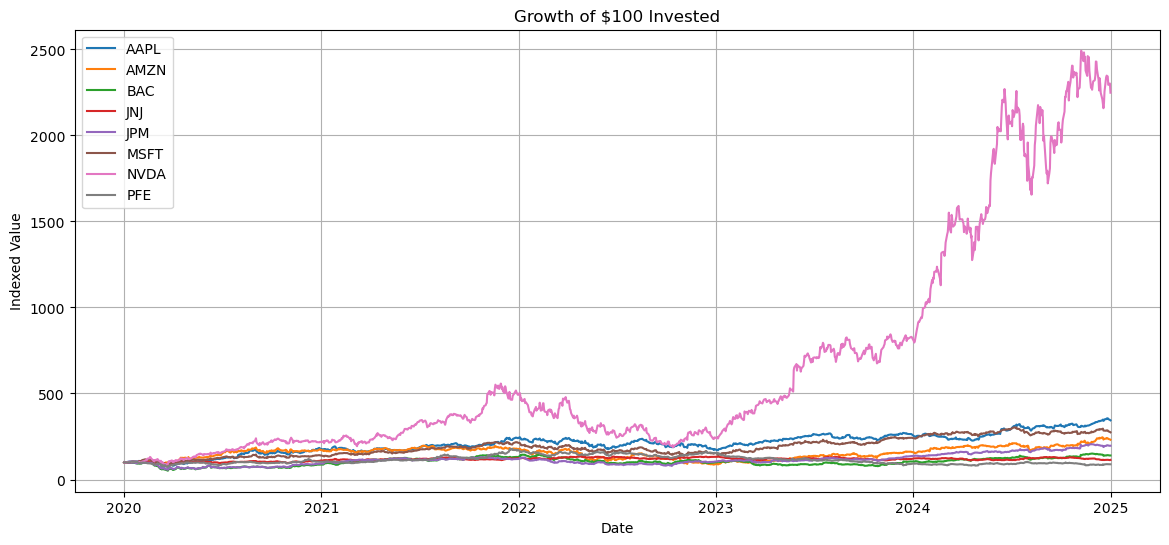

In [20]:
plt.figure(figsize=(14, 6))

for ticker in norm_stocks_df["Ticker"].unique():
    temp = norm_stocks_df[norm_stocks_df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Normalized_Price"], label=ticker)

plt.title("Growth of $100 Invested")
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend()
plt.grid(True)
plt.show()

##### Investment performance

In [21]:
investment_summary = norm_stocks_df.groupby("Ticker").agg(Final_Investment_Value=("Normalized_Price", "last"))
investment_summary["Investment_Gain"] = investment_summary["Final_Investment_Value"] - 100
investment_summary = investment_summary.sort_values("Investment_Gain", ascending=False)
investment_summary

,Final_Investment_Value,Investment_Gain
Ticker,,
NVDA,2248.393096,2148.393096
AAPL,344.002261,244.002261
MSFT,274.359251,174.359251
AMZN,231.178977,131.178977
JPM,196.315301,96.315301
BAC,139.643919,39.643919
JNJ,113.816489,13.816489
PFE,88.497795,-11.502205


##### Conclusions

- **If $100 were invested in each stock, which produced the highest wealth?**  
Nvidia - `$100` became `$2248.39`

- **Which stock destroyed value?**  
Pfizer

## Return analysis
Objective: Understand return consistency and distribution

### Daily Returns and Cumulative Returns

In [26]:
returns = stocks_df[["Ticker", "Date", "Close"]].copy()
returns["Daily_Return"] = stocks_df.groupby("Ticker")["Close"].pct_change()
returns["Cumulative_Return"] = returns.groupby("Ticker")["Daily_Return"].transform(lambda x: (1 + x).cumprod() - 1)

returns

,Ticker,Date,Close,Daily_Return,Cumulative_Return
0,AAPL,2020-01-02,72.333885,NaN,NaN
1,AAPL,2020-01-03,71.630638,-0.009722,-0.009722
2,AAPL,2020-01-06,72.201416,0.007968,-0.001831
3,AAPL,2020-01-07,71.861839,-0.004703,-0.006526
4,AAPL,2020-01-08,73.017838,0.016086,0.009455
...,...,...,...,...,...
8801,PFE,2024-12-24,24.126684,0.001123,-0.108017
8802,PFE,2024-12-26,23.964275,-0.006732,-0.114021
8803,PFE,2024-12-27,24.018414,0.002259,-0.112020
8804,PFE,2024-12-30,23.837957,-0.007513,-0.118691


##### Final Cumulative return

In [32]:
returns.groupby("Ticker")["Cumulative_Return"].last().sort_values(ascending=False)

Ticker
NVDA    21.483931
AAPL     2.440023
MSFT     1.743593
AMZN     1.311790
JPM      0.963153
BAC      0.396439
JNJ      0.138165
PFE     -0.115022
Name: Cumulative_Return, dtype: float64

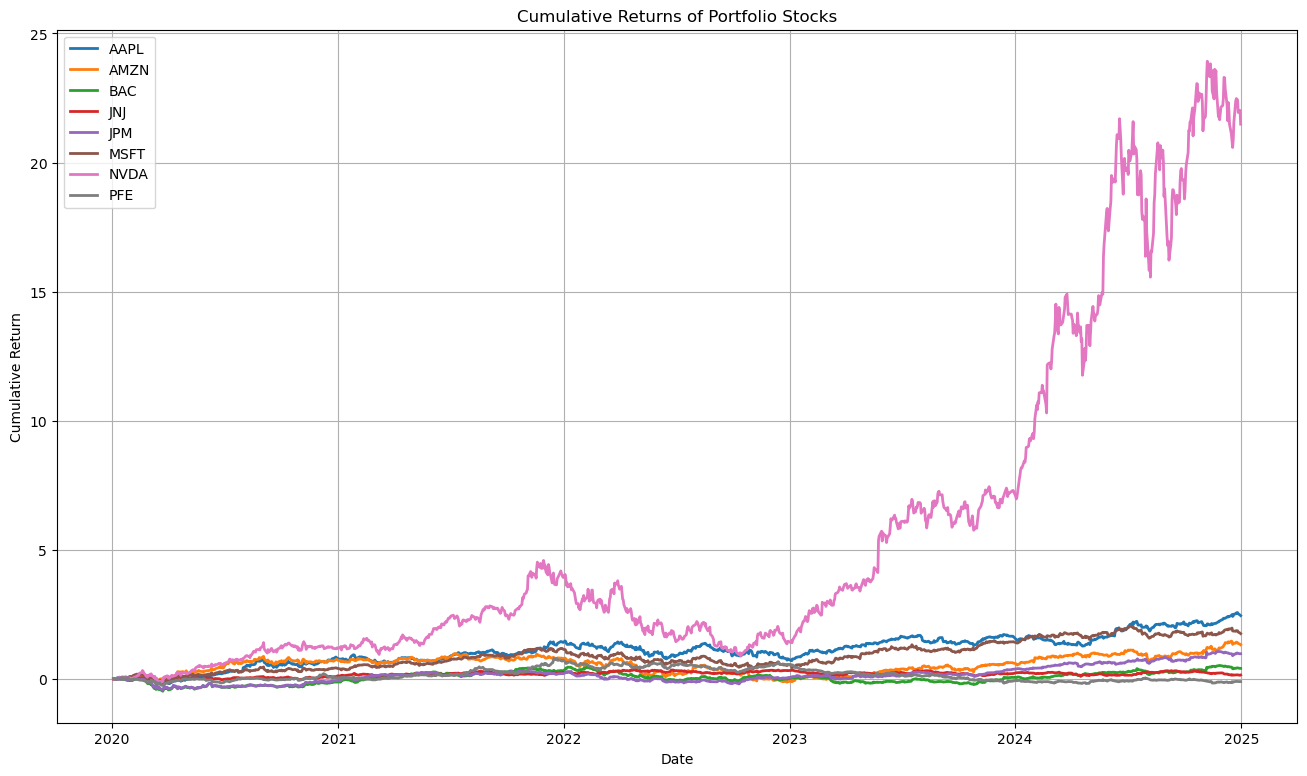

In [36]:
plt.figure(figsize=(16, 9))

for ticker in returns["Ticker"].unique():
    temp = returns[returns["Ticker"] == ticker]
    plt.plot(
        temp["Date"],
        temp["Cumulative_Return"],
        linewidth=2,
        label=ticker
    )
plt.title("Cumulative Returns of Portfolio Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.show()

##### Underwater days

In [37]:
underperformance = returns.groupby("Ticker").agg(Days_Underwater=("Cumulative_Return", lambda x: (x < 0).sum()))
underperformance.sort_values("Days_Underwater", ascending=False)

,Days_Underwater
Ticker,
BAC,563
PFE,511
JPM,412
AMZN,84
JNJ,69
AAPL,53
MSFT,23
NVDA,10


##### Conclusions

- **Which stock generated the highest cumulative return?**  
Based upon price appreciation calculations, NVIDA generated highest cumulative return (price appreciation: `2148.39%`).

- **Which stock experienced prolonged period of underperformance?**  
Bank of America spent `563` trading days below its inital investment value. Pfizer and JPMorgan also remained underwayer for extended periods, indicating slow recovery. 

### Return distribution

#### Daily returns distribution 

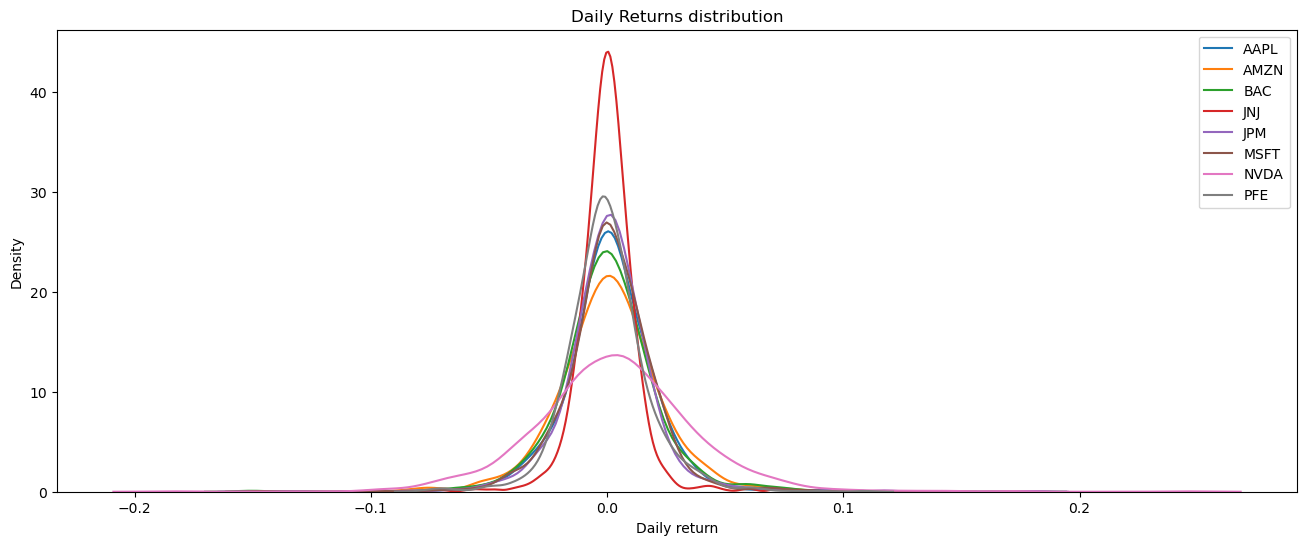

In [23]:
import seaborn as sns

plt.figure(figsize=(16, 6))

for ticker in returns["Ticker"].unique():
    daily_return = returns.loc[returns["Ticker"] == ticker]
    daily_return = daily_return["Daily_Return"].dropna()
    sns.kdeplot(daily_return, label=ticker, fill=False)

plt.title("Daily Returns distribution")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()
plt.show()

##### Return distribution

In [25]:
import numpy as np

return_distribution = returns.groupby("Ticker").agg(
    Mean_Return=("Daily_Return", "mean"),
    Median_Return=("Daily_Return", "median"),
    Std_Dev=("Daily_Return", "std"),
    Min_Return=("Daily_Return", "min"),
    Max_Return=("Daily_Return", "max"),
    Skewness=("Daily_Return", "skew"),
    Kurtosis=("Daily_Return", lambda x: x.kurt()),
)
return_distribution["Max_Abs_Move"] = returns.groupby("Ticker")["Daily_Return"].apply(lambda x: x.abs().max())
return_distribution["Annualized_Return"] = return_distribution["Mean_Return"] * 252
return_distribution["Ananualized_Volatality"] = return_distribution["Std_Dev"] * np.sqrt(252)

return_distribution.sort_values(by="Annualized_Return", ascending=False)

,Mean_Return,Median_Return,Std_Dev,Min_Return,Max_Return,Skewness,Kurtosis,Max_Abs_Move,Annualized_Return,Ananualized_Volatality
Ticker,,,,,,,,,,
NVDA,0.003050,0.003291,0.033940,-0.184521,0.243696,0.415479,4.012308,0.243696,0.768567,0.538788
AAPL,0.001182,0.001187,0.019956,-0.128647,0.119809,0.105626,5.277834,0.128647,0.297892,0.316786
MSFT,0.000988,0.001111,0.019211,-0.147390,0.142169,-0.016823,7.120321,0.147390,0.248931,0.304972
AMZN,0.000923,0.000782,0.022655,-0.140494,0.135359,0.070445,3.995553,0.140494,0.232658,0.359639
JPM,0.000746,0.000709,0.020490,-0.149649,0.180125,0.448238,12.950860,0.180125,0.187930,0.325266
BAC,0.000518,0.000214,0.022515,-0.153973,0.177962,0.467117,10.476733,0.177962,0.130501,0.357418
JNJ,0.000179,0.000122,0.012382,-0.072984,0.079977,0.434982,8.294484,0.079977,0.045193,0.196566
PFE,0.000052,-0.000833,0.017306,-0.077346,0.108552,0.369029,3.903735,0.108552,0.013084,0.274725


##### Conclusions

- **Which stock has the widest return distribution?**  
NVIDIA shows the widest return distribution with a daily return std of `3.39%`, suggesting greatest short-term risk but potential for higher returns.

- **Which stock is relatively stable?**  
Johnson and Johnson is the most stable return profile, with the lowest daily return voltality of `1.24%`.

- **Which stock experiences more extreme daily movements?**  
NVIDIA shows the most extreme daily movement, with a maximum absolute daily return of `24.37%`.

- **Which stock generates the highest average daily return?**  
NVIDIA

- **Which stock consistently underperforms?**  
Pfizer consistently underperformed, recording the lowest avg. daily return `0.005%`.

- **Which stock provides the highest expected yearly return?**  
NVIDIA provies highest expected yearly return of `76.86%`.

- **Does the ranking differ from total price appreciation?**  
The ranking is identical to the ranking based on total price appreciation, which indicates that stocks delivering superior long-term capital appreciation also generated higher average daily returns.

- **Which stock had the strongest single-day rally?**  
NVIDIA gained `24.37%` in one trading session.

- **Which stock experienced the largest one-day loss?**  
NVIDIA; and this shows high-risk and high-reward profile.

## Volatility Analysis

Objective: Analyze variability and stability of stock to evaluate investment risk